In [1]:
# pip installs

import cv2
import os
import PIL
import random
import zipfile
import shutil
import zipfile

from matplotlib import pyplot as plt
from torchvision.datasets import CelebA
from tqdm import tqdm

from google.colab import drive
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
from torch.utils.data import DataLoader, Subset

RUN_TESTS = True

# CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# set default dtype to control memory usage
dtype = torch.float32

Using device: cuda



In [3]:
COLOR_RANGE = [-1, 1]
COLOR_SPECTRUM = 3
HEIGHT = 216
WIDTH = 176


transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomRotation(10),
        torchvision.transforms.CenterCrop((HEIGHT, WIDTH)),  # Crop to 216x176 pixels
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5,), (0.5,)),
    ]
)
dataset = CelebA("./data", split="train", download=True, transform=transform)


# clip images to COLOR_RANGE
def clip_images(images, range=COLOR_RANGE):
    return images.clamp(min=range[0], max=range[1])


# helper function to convert GPU tensor to image on CPU
def tensor_to_image(x, permute=True):
    if len(x.shape) == 4:
        x = x[0]  # take first image in batch

    # if it contains values between -1 and 0, scale to [0, 1]
    x = clip_images(x)
    if x.min() < 0:
        x = (x + 1) / 2

    if permute:
        x = x.permute(1, 2, 0)
    x = x.to(torch.float32).cpu().detach().numpy()
    x = np.clip(x, 0, 1)
    return x

Files already downloaded and verified


In [4]:
# Noise schedule defines how much noise is added at each time step
class Schedule:
    def __init__(self, T, beta_1=0.0001, beta_T=0.02, type="linear"):
        assert 0 < beta_1 < beta_T < 1, f"Invalid beta values: {beta_1}, {beta_T}"
        if type == "linear":
            self.beta = torch.linspace(beta_1, beta_T, T + 1)
            self.alpha = 1 - self.beta
        elif type == "cosine":
            t = torch.linspace(0, T - 1, T)
            precomputed = np.pi / 2 / T
            self.alpha = torch.cos(t * precomputed) ** 2
            self.beta = 1 - self.alpha
        else:
            raise ValueError(f"Unknown schedule type: {type}")

        self.T = T
        self.alpha_bar = torch.cumprod(self.alpha, 0)  # product of all elements in alpha from 0 to t
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)  # needed for noise generation and repainting
        self.one_minus_alpha_bar = 1 - self.alpha_bar  # needed for repainting
        self.sqrt_one_minus_alpha_bar = torch.sqrt(self.one_minus_alpha_bar)  # needed for noise generation
        self.one_over_sqrt_alpha = 1 / torch.sqrt(self.alpha)  # needed for sampling
        self.sqrt_beta = torch.sqrt(self.beta)  # please kill me
        self.beta_over_sqrt_one_minus_alpha_bar = self.beta / self.sqrt_one_minus_alpha_bar  # needed for sampling

    def to(self, device=device):
        self.alpha = self.alpha.to(device)
        self.beta = self.beta.to(device)
        self.alpha_bar = self.alpha_bar.to(device)
        self.sqrt_alpha_bar = self.sqrt_alpha_bar.to(device)
        self.one_minus_alpha_bar = self.one_minus_alpha_bar.to(device)
        self.sqrt_one_minus_alpha_bar = self.sqrt_one_minus_alpha_bar.to(device)
        self.one_over_sqrt_alpha = self.one_over_sqrt_alpha.to(device)
        self.sqrt_beta = self.sqrt_beta.to(device)
        self.beta_over_sqrt_one_minus_alpha_bar = self.beta_over_sqrt_one_minus_alpha_bar.to(device)
        return self


# typical values
T = 1000
beta_1 = 0.0001
beta_T = 0.02

In [5]:
# Swish activation function, similar to ReLU but with a smoother gradient
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class ResBlock(nn.Module):
    def __init__(self, num_channels, time_embedding_dim, dropout_rate=0):
        super().__init__()
        self.activation = Swish()
        self.norm1 = nn.GroupNorm(num_groups=8, num_channels=num_channels)
        self.norm2 = nn.GroupNorm(num_groups=8, num_channels=num_channels)
        self.conv1 = nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=dropout_rate)
        # project time embedding to desired channel dimension,
        # since each resblock requires an embedding of the same dimension as the input
        self.time_mlp = nn.Linear(time_embedding_dim, num_channels)

    def forward(self, x, time_embedding):
        x = x + self.time_mlp(time_embedding).unsqueeze(-1).unsqueeze(-1)
        residual = x
        x = self.activation(self.norm1(self.conv1(x)))
        x = self.dropout(x)
        x = self.activation(self.norm2(self.conv2(x)))
        return x + residual


class AttentionBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, dropout_rate=0):
        super().__init__()
        # copied from assignment 3 and modified
        self.num_heads = num_heads  # Number of attention heads
        self.embedding_dim = embedding_dim  # Embedding dimensionality
        assert embedding_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads."

        # Maps embedding into Q, K, V. We'll use one layer to generate these matrices for all heads at once.
        self.qkv_map = nn.Linear(embedding_dim, 3 * embedding_dim)

        # After performing attention for each head individually, we concat the results
        # and feed them through this linear layer.
        self.final_projection = nn.Linear(embedding_dim, embedding_dim)
        self.final_dropout = nn.Dropout(dropout_rate)  # regularization

    def forward(self, x):
        torch.cuda.empty_cache()
        H, W = x.shape[2], x.shape[3]
        x = x.flatten(2, 3).permute(0, 2, 1)  # reshape image to sequence (B, C, H, W) => (B, T, C)
        B, T, C = x.shape  # B: batch size, T: sequence length, C: embedding dimension
        d_k = C // self.num_heads  # dimension of q/k/v vectors

        # compute queries, keys, values with a single projection
        qkv = self.qkv_map(x)
        Q, K, V = torch.chunk(qkv, 3, dim=-1)
        # split into num_heads, (B, num_heads, T, d_k)
        Q = Q.reshape(B, T, self.num_heads, d_k).transpose(1, 2)
        K = K.reshape(B, T, self.num_heads, d_k).transpose(1, 2)
        V = V.reshape(B, T, self.num_heads, d_k).transpose(1, 2)
        torch.cuda.empty_cache()

        # compute similarity between queries and keys
        # compute attention weights based on similarity
        # update embeddings with weighted values
        S = Q @ K.transpose(-2, -1) / np.sqrt(d_k)
        A = F.softmax(S, dim=-1)
        out = A @ V

        # project output of attention mechanism back to original embedding dimension
        out = out.transpose(1, 2).reshape(B, T, C)  # (B, num_heads, T, d_k) => (B, T, C)
        out = self.final_dropout(self.final_projection(out))
        out = out.reshape(B, C, H, W)  # (B, T, C) => (B, C, H, W)
        torch.cuda.empty_cache()
        return out


# generate time embeddings for UNet using a MLP
class MLPTimeEmbedding(nn.Module):
    def __init__(self, T, embedding_dim):
        super().__init__()
        self.T = T
        self.mlp = nn.Sequential(
            nn.Linear(1, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, t):
        t = t.to(dtype).unsqueeze(-1)  # convert int to float
        assert (t >= 0).all() and (t <= self.T).all()
        t = t / self.T  # normalize to [0, 1]
        time_embedding = self.mlp(t)
        assert torch.isfinite(time_embedding).all(), f"Found NaNs or Infs in time embedding"
        return time_embedding

In [6]:
# UNetLayer: 2 ResBlocks with an optional AttentionBlock in between followed by a final Up/Downsampling block
use_attention = True


class UNetLayer(nn.Module):
    def __init__(self, type, num_channels, time_embedding_dim, num_heads=0):
        super().__init__()
        self.type = type
        self.res1 = ResBlock(num_channels, time_embedding_dim)
        self.res2 = ResBlock(num_channels, time_embedding_dim)
        self.num_heads = num_heads
        if use_attention:
            if num_heads:
                self.attention = AttentionBlock(num_channels, num_heads)

        if type == "down":
            self.conv = nn.Conv2d(num_channels, num_channels * 2, kernel_size=3, stride=2, padding=1)
        elif type == "up":
            self.conv = nn.ConvTranspose2d(
                num_channels, num_channels // 2, kernel_size=3, stride=2, padding=1, output_padding=1
            )
        else:
            raise ValueError(f"Unknown layer type: {type}")

    def forward(self, x, time_embeddings):
        x = self.res1(x, time_embeddings)
        if use_attention:
            if self.num_heads:
                x = self.attention(x)
        x = self.res2(x, time_embeddings)
        return self.conv(x), x  # up/downsampled version + residual

In [7]:
# UNet model which takes a noisy image and a time index and predicts the variance of the noise
class UNet(nn.Module):
    def __init__(
        self,
        T,
        depth=3,
        initial_channels=64,
        time_embedding_dim=32,
        num_heads=0,
    ):
        super(UNet, self).__init__()

        self.activation = Swish()  # nn.ReLU()
        self.time_embedding = MLPTimeEmbedding(T, time_embedding_dim)

        # dynamic channel calculation based on depth
        # downsampling reduces the image size by a factor of 2 but doubles the number of channels
        down_channels = []
        for i in range(depth):
            down_channels.append(initial_channels * (2**i))

        # upsampling halves the number of channels but doubles the image size
        up_channels = [down_channels[-1] * 2]  # bottleneck without skip connection
        for i in range(depth - 1, 0, -1):
            up_channels.append(down_channels[i] + up_channels[-1] // 2)
        final_channels = up_channels[-1] // 2 + down_channels[0]

        # initial convolution to map input to desired number of initial channels
        self.conv1 = nn.Conv2d(COLOR_SPECTRUM, down_channels[0], kernel_size=3, padding=1)

        # down layers which produce skip connections
        self.down_layers = nn.ModuleList(
            [
                UNetLayer("down", down_channels[0], time_embedding_dim),
                UNetLayer("down", down_channels[1], time_embedding_dim, num_heads),
                UNetLayer("down", down_channels[2], time_embedding_dim),
            ]
        )
        self.bottleneck = UNetLayer("up", up_channels[0], time_embedding_dim)
        # up layers which receive skip connections
        self.up_layers = nn.ModuleList(
            [
                UNetLayer("up", up_channels[1], time_embedding_dim),
                UNetLayer("up", up_channels[2], time_embedding_dim, num_heads),
            ]
        )

        # convolution to half the number of channels, also receives skip connection
        self.final1 = nn.Conv2d(final_channels, final_channels // 2, kernel_size=3, padding=1)
        # final layer to map back to RGB
        self.final2 = nn.Conv2d(final_channels // 2, COLOR_SPECTRUM, kernel_size=3, padding=1)
        self.norm = nn.GroupNorm(num_groups=8, num_channels=final_channels // 2)

    def forward(self, x, t):
        H, W = x.shape[2:]
        depth = len(self.down_layers)
        assert H % (2**depth) == 0 and W % (2**depth) == 0, "Image size must be divisible by 2^depth"

        time_embedding = self.time_embedding(t)
        x = self.activation(self.conv1(x))

        # downsample and store intermediates for skip connections
        residuals = []
        for down in self.down_layers:
            x, r = down(x, time_embedding)
            residuals.append(r)

        # bottleneck without skip connection
        x, _ = self.bottleneck(x, time_embedding)

        # upsample and concatenate skip connections
        residuals = residuals[::-1]  # add residuals in reverse order
        for i in range(len(self.up_layers)):
            x = torch.cat([x, residuals[i]], dim=1)
            x, _ = self.up_layers[i](x, time_embedding)

        # final two convolutions back to RGB
        x = torch.cat([x, residuals[-1]], dim=1)  # final residual
        # x = self.activation(self.conv2(x))
        x = self.activation(self.norm(self.final1(x)))
        return self.final2(x)

In [8]:
class DDPM(nn.Module):
    def __init__(self, schedule, sigma_t=0.05):
        super(DDPM, self).__init__()
        self.schedule = schedule.to(device)  # defines how much noise is added at each time step
        self.noise_predictor = UNet(schedule.T)  # predicts noise given a noisy image and a time t
        self.sigma_t = sigma_t  # variance of noise which is added back during sampling
        self.losses = []  # store training losses
        self.to(device)

    # generate noisy version of the image: x_0 => x_t
    @torch.no_grad()
    def forward_diffusion(self, x_0, t):
        epsilon = torch.randn(x_0.shape).to(device)  # add random noise
        sqrt_alpha_bar_t = self.schedule.sqrt_alpha_bar[t].view(-1, 1, 1, 1)  # broadcast to batch size
        sqrt_one_minus_alpha_bar_t = self.schedule.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        x_t = sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * epsilon  # add noise for first t time steps
        return x_t, epsilon

    # generates images from complete noise
    # https://arxiv.org/pdf/2006.11239, algorithm 2, page 4
    @torch.no_grad()
    def generate_images(self, num_images=1, shape=(COLOR_SPECTRUM, HEIGHT, WIDTH)):
        # shape: (C, H, W) => (num_images, C, H, W)
        shape = (num_images, *shape)  # generate a batch of images
        x_t = torch.randn(shape).to(device)  # complete random noise x_T
        one_over_sqrt_alpha = self.schedule.one_over_sqrt_alpha
        beta_over_sqrt_one_minus_alpha_bar = self.schedule.beta_over_sqrt_one_minus_alpha_bar
        sqrt_beta = self.schedule.sqrt_beta

        # source: "P12.ipynb"
        for t in range(self.schedule.T, 0, -1):
            # predict variance of noise and remove the noise from the image
            # broadcast scalars to batch size
            z = torch.randn(shape).to(device) if t > 1 else 0
            t_vector = torch.zeros(num_images).to(device).float() + t
            prediction = self.noise_predictor(x_t, t_vector)
            # remove predicted noise
            x_t = one_over_sqrt_alpha[t] * (x_t - beta_over_sqrt_one_minus_alpha_bar[t] * prediction)
            x_t += z * sqrt_beta[t]  # add noise back
        return x_t

    # RePaint: https://arxiv.org/pdf/2201.09865, algorithm 1, page 5
    @torch.no_grad()
    def inpaint(self, image, mask, resample_steps=10):
        # mask with same dimensions as image with 1 where image is known and 0 where image is missing
        mask_known = mask
        mask_unknown = 1 - mask

        sqrt_alpha_bar = self.schedule.sqrt_alpha_bar
        one_minus_alpha_bar = self.schedule.one_minus_alpha_bar
        one_over_sqrt_alpha = self.schedule.one_over_sqrt_alpha
        beta_over_sqrt_one_minus_alpha_bar = self.schedule.beta_over_sqrt_one_minus_alpha_bar
        sqrt_one_minus_alpha_bar = self.schedule.sqrt_one_minus_alpha_bar

        x_t = torch.randn(image.shape).to(device)  # complete random noise
        # repeat from complete noise x_unknown_T to restored pixels x_unknown_0
        for t in reversed(range(self.schedule.T)):  # T-1 to 0
            torch.cuda.empty_cache()
            # resample for each time step except the last one
            for u in range(1, resample_steps + 1):  # 1 to resample_steps
                torch.cuda.empty_cache()
                # define noise epsilon and z which are added back (except for t=0)
                if t > 0:
                    epsilon = torch.randn(image.shape).to(device)
                    z = torch.randn(image.shape).to(device)
                else:
                    epsilon = torch.zeros(image.shape).to(device)
                    z = torch.zeros(image.shape).to(device)

                # forward diffusion step => harmonize known and unknown pixels
                x_known_t = sqrt_alpha_bar[t] * image + one_minus_alpha_bar[t] * epsilon

                # predict variance of noise and remove the noise from the image
                t_vector = torch.full((1,), t).to(device)  # vector of t for all images
                predicted_noise = self.noise_predictor(x_t, t_vector)
                x_unknown_t = one_over_sqrt_alpha[t] * (x_t - beta_over_sqrt_one_minus_alpha_bar[t] * predicted_noise)
                x_unknown_t += self.schedule.sqrt_beta[t] * z  # add noise back

                # combine unmasked pixels of x_known_t and masked pixels of x_unknown_t
                known = x_known_t * mask_known  # set unknown pixels to 0
                unknown = x_unknown_t * mask_unknown  # set known pixels to 0
                x_t = known + unknown

                if u < resample_steps and t > 0:
                    noise = torch.randn(image.shape).to(device)
                    x_t = sqrt_alpha_bar[t] * x_t + sqrt_one_minus_alpha_bar[t] * noise

        return clip_images(x_t)

    def save_checkpoint(self, epoch, optimizer, checkpoint_path):
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": self.losses,
        }
        torch.save(checkpoint, checkpoint_path)

    def load_checkpoint(self, checkpoint_path, optimizer):
        checkpoint = torch.load(checkpoint_path)
        self.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        return checkpoint["epoch"], checkpoint["train_losses"]

In [9]:
# https://arxiv.org/pdf/2006.11239, algorithm 1, page 4
def train(model, data_loader, epochs=100, lr=0.0001, checkpoint_path="", checkpoint_interval=10):
    torch.cuda.empty_cache()  # release allocated but unused GPU memory
    optimizer = torch.optim.Adam(model.noise_predictor.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        pbar = tqdm(data_loader)
        for images, _ in pbar:
            images = images.to(device)
            # create random noise at random time index
            t = torch.randint(0, model.schedule.T, (len(images),), device=device)

            # L_simple, https://arxiv.org/pdf/2006.11239, page 5
            noisy_images, noise = model.forward_diffusion(images, t)

            optimizer.zero_grad()
            predicted_noise = model.noise_predictor(noisy_images, t)
            loss = F.mse_loss(predicted_noise, noise)
            total_loss += loss.item()

            # backpropagation
            loss.backward()
            optimizer.step()

        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {total_loss / len(data_loader):.4f}")
        model.losses.append(total_loss / len(data_loader))

        # save checkpoint
        if checkpoint_path and (epoch + 1) % checkpoint_interval == 0:
            model.eval()

            num_images = 4
            generated_image = ddpm.generate_images(num_images)
            for i in range(num_images):
                plt.subplot(1, num_images, i + 1)
                plt.axis("off")
                plt.imshow(tensor_to_image(generated_image[i : i + 1]))
            plt.show()

            model.train()
            model.save_checkpoint(epoch, optimizer, checkpoint_path)

    torch.cuda.empty_cache()
    model.eval()
    return model.losses

In [10]:
# create model for actual training
batch_size = 32
T = 1000
schedule = Schedule(T, beta_1, beta_T)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)
ddpm = DDPM(schedule)

out_dir = "models"
os.makedirs(out_dir, exist_ok=True)  # Create output directory

num_params = sum([x.numel() for x in ddpm.parameters() if x.requires_grad])
print(f"Number of parameters: {num_params/1e6:.2f}M")

Number of parameters: 32.30M


In [13]:
if os.path.exists("models/ddpm_checkpoint.save"):
    # if model was already trained, we simply load it since training it took around 16.5h (with A100 GPU)
    checkpoint = torch.load("models/ddpm_checkpoint.save", map_location=device)
    ddpm.load_state_dict(checkpoint["model_state_dict"])
    ddpm.losses = checkpoint["train_losses"]
else:
    # train for a while and generate images
    train(
        ddpm,
        dataloader,
        epochs=26,
        checkpoint_path="models/ddpm_checkpoint.save",
        checkpoint_interval=2,
    )

<ipython-input-13-3fd3c5eeb479>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/ddpm_checkpoint.save", map_location=device)


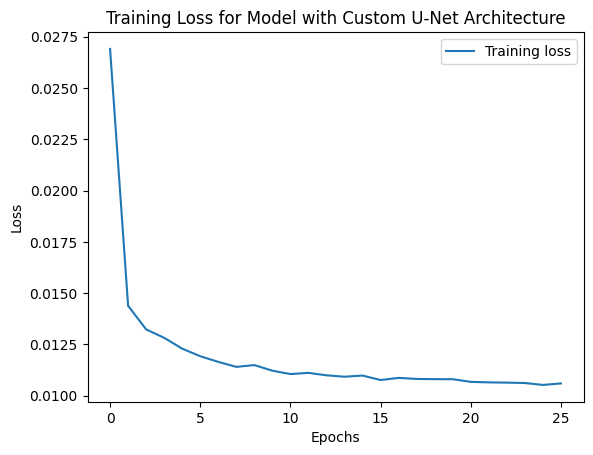

In [14]:
# Plotting loss function
plt.plot(ddpm.losses, label='Training loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss for Model with Custom U-Net Architecture')
plt.show()